In [12]:
pip install libpysal

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install esda

Note: you may need to restart the kernel to use updated packages.


In [14]:
import geopandas as gpd
import pandas as pd
import libpysal
from libpysal.weights import Queen, higher_order
from esda.moran import Moran
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import KNN

In [15]:
# setting wd 
import os
#os.chdir('/users/sarazarea26/fooddesertproject')

In [16]:
import geopandas as gpd
import numpy as np

# Load GeoPackage
dallas = gpd.read_file("dallas_modeling_final.gpkg")
tarrant = gpd.read_file("tarrant_modeling_final.gpkg")
travis = gpd.read_file("travis_modeling_final.gpkg")
bexar = gpd.read_file("bexar_modeling_final.gpkg")
harris = gpd.read_file("harris_modeling_final.gpkg")

In [17]:
# Reproject all counties to the same CRS
target_crs = "EPSG:3083"

dallas = dallas.to_crs(target_crs)
tarrant = tarrant.to_crs(target_crs)
travis = travis.to_crs(target_crs)
bexar = bexar.to_crs(target_crs)
harris = harris.to_crs(target_crs)

In [18]:
#merge 
dallas["county"] = "Dallas"
tarrant["county"] = "Tarrant"
travis["county"] = "Travis"
bexar["county"] = "Bexar"
harris["county"] = "Harris"

all_counties = pd.concat(
    [dallas, tarrant, travis, bexar, harris],
    ignore_index=True
)

In [19]:
all_counties.to_csv("all_counties.csv", index=False)

In [20]:
county = "dallas"

In [21]:
gdf = gpd.read_file(f"all_counties.gpkg")
print(gdf.shape)  
gdf.columns

(3123, 25)


Index(['COUNTY', 'GEOID', 'tract', 'walking_ind', 'walkind_inv_perc',
       'total_pop', 'total_pop_moe', 'below_200_fed_poverty_percentage',
       'no_hs_diploma', 'uninsured', 'E_CHD', 'E_DIABETES', 'E_AFAM',
       'E_ASIAN', 'E_HISP', 'median_age', 'ALAND', 'AWATER',
       'distance_to_nearest_grocery', 'distance_to_nearest_fm',
       'distance_to_nearest_uf', 'median_income', 'pct_no_vehicle',
       'county_name', 'geometry'],
      dtype='str')

In [22]:
# gdf = gdf.dropna(subset=["median_income"]).copy()
# print(gdf_income.shape)  

In [23]:
# only use when calculating k, otherwise comment out 
n = len(gdf)
k = round(n ** (1/3))
print(f"Number of census tracts: {n}")
print(f"Cube root of n: {n**(1/3):.2f}")
print(f"Selected k: {k}")

Number of census tracts: 3123
Cube root of n: 14.62
Selected k: 15


In [24]:
# build first-order contiguity weights
# w1 = Queen.from_dataframe(gdf, use_index=True)

w1 = KNN.from_dataframe(gdf, k=k, use_index=True)
print(w1.n)

3123


c:\Users\saraz\anaconda3\envs\pandas\Lib\site-packages\libpysal\weights\distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [25]:
def run_correlogram(var_name, gdf, w1, max_lag=6):
    var = gdf[var_name].values
    results = []
    for lag in range(1, max_lag + 1):
        w_lag = higher_order(w1, lag)
        w_lag.transform = "R"
        mi = Moran(var, w_lag, permutations=999)
        results.append({
            "variable": var_name,
            "lag": lag,
            "I": mi.I,
            "expected_I": mi.EI,
            "se_I": mi.seI_sim,
            "p_sim": mi.p_sim
        })
    return pd.DataFrame(results)


# run the three variables
diabetes_df = run_correlogram("E_DIABETES", gdf, w1)
chd_df = run_correlogram("E_CHD", gdf, w1)
walking_df = run_correlogram("walking_ind", gdf, w1)
poverty_df = run_correlogram("below_200_fed_poverty_percentage", gdf, w1)
uninsured_df = run_correlogram("uninsured", gdf, w1)
uf_df = run_correlogram("distance_to_nearest_uf", gdf, w1)
# income_df = run_correlogram("median_income", gdf, w1)
grocery_df = run_correlogram("distance_to_nearest_grocery", gdf, w1)
# mobility_df= run_correlogram("pct_no_vehicle", gdf, w1)
fm_df= run_correlogram("distance_to_nearest_fm", gdf, w1)


# combine and save the table
all_results = pd.concat([diabetes_df, chd_df, walking_df, poverty_df, uninsured_df, uf_df, grocery_df, fm_df], ignore_index=True)
all_results.to_csv(f"{county}_correlogram_results_KNN.csv", index=False)
all_results

c:\Users\saraz\anaconda3\envs\pandas\Lib\site-packages\libpysal\weights\util.py:544: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  return W(neighbors=d, **kwargs)


,variable,lag,I,expected_I,se_I,p_sim
0,E_DIABETES,1,0.199615,-0.00032,0.006268,0.001
1,E_DIABETES,2,-0.006704,-0.00032,0.004110,0.046
2,E_DIABETES,3,-0.005524,-0.00032,0.003373,0.050
3,E_DIABETES,4,0.002592,-0.00032,0.002859,0.166
4,E_DIABETES,5,0.005652,-0.00032,0.002527,0.014
5,E_DIABETES,6,0.005655,-0.00032,0.002507,0.018
6,E_CHD,1,0.199041,-0.00032,0.006017,0.001
7,E_CHD,2,-0.008160,-0.00032,0.004094,0.017
8,E_CHD,3,-0.007209,-0.00032,0.003299,0.009
9,E_CHD,4,0.001240,-0.00032,0.003030,0.286


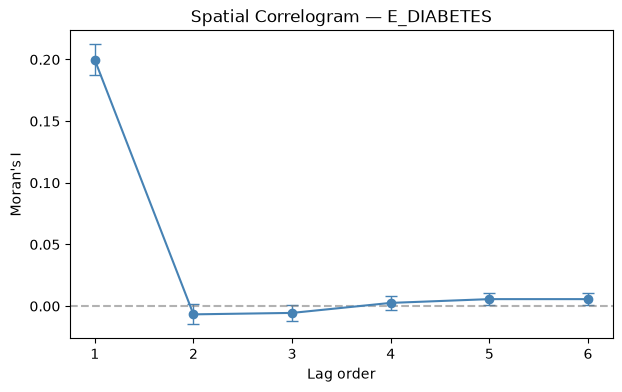

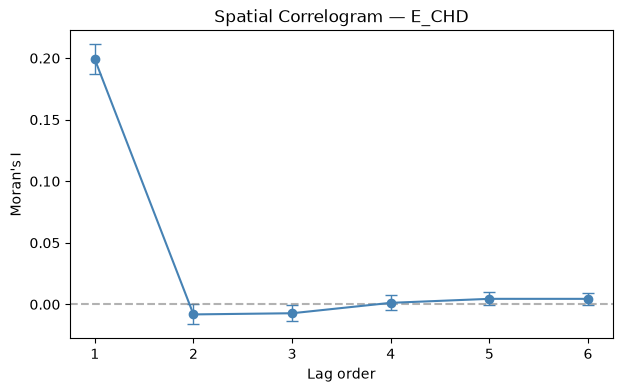

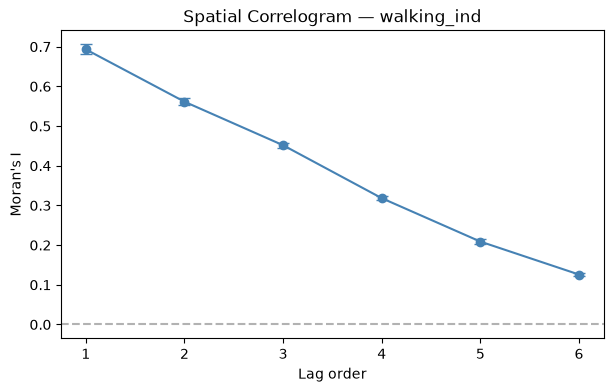

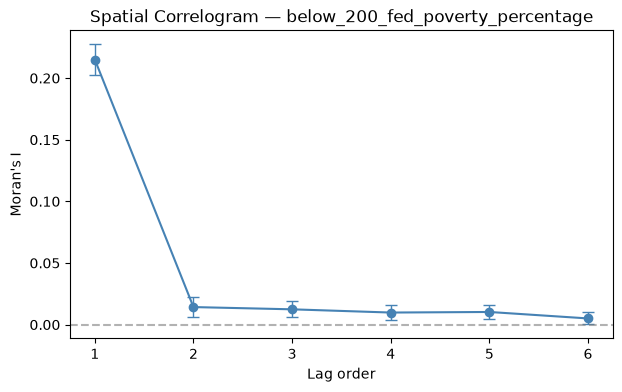

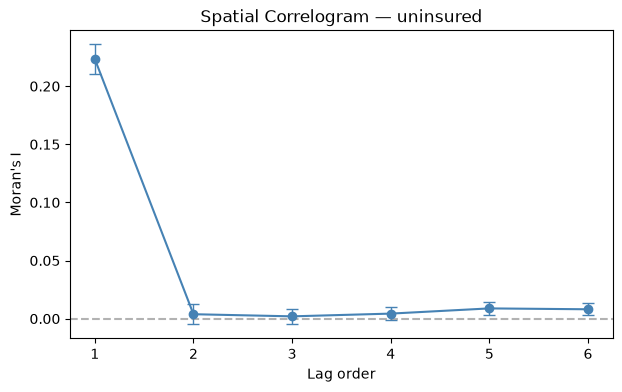

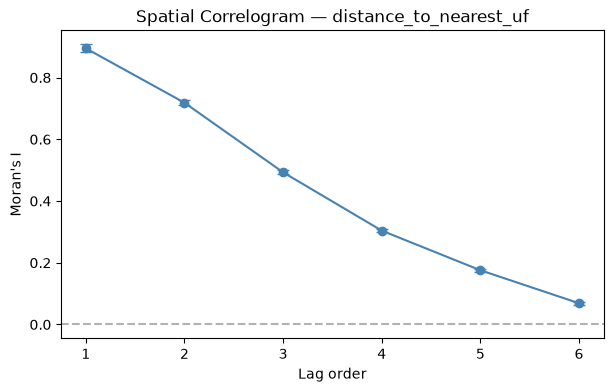

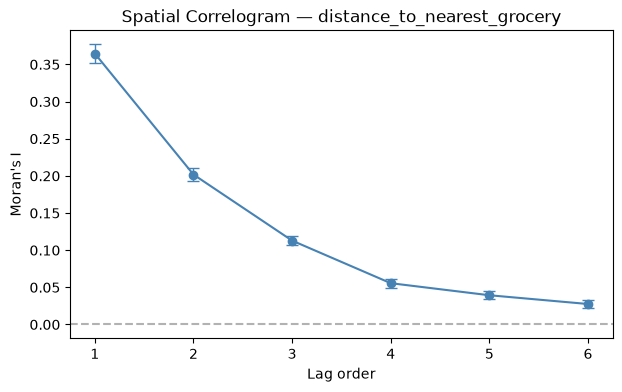

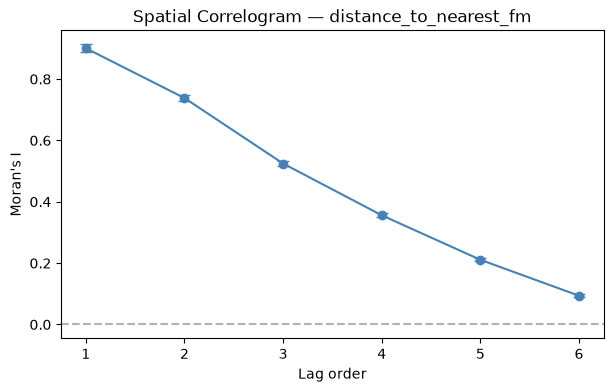

In [29]:
# now plot and save
for var_name, df in [
    ("E_DIABETES", diabetes_df),
    ("E_CHD", chd_df),
    ("walking_ind", walking_df),
    ("below_200_fed_poverty_percentage", poverty_df),
    ("uninsured", uninsured_df),
    ("distance_to_nearest_uf", uf_df),
    ("distance_to_nearest_grocery", grocery_df),
    ("distance_to_nearest_fm", fm_df)
]:
    plt.figure(figsize=(7, 4))

    plt.errorbar(
        df["lag"],
        df["I"],
        yerr=2 * df["se_I"],
        marker="o",
        color="steelblue",
        ecolor="steelblue",
        elinewidth=1,
        capsize=4
    )

    plt.axhline(0, color="gray", linestyle="--", alpha=0.6)
    plt.xlabel("Lag order")
    plt.ylabel("Moran's I")
    plt.title(f"Spatial Correlogram — {var_name}")

    plt.savefig(
        f"{county}_correlogram_{var_name}_KNN.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()